# PredictCareAI xAI - Readmission Model-only Notebook

Notebook này chỉ phục vụ **phần model/xAI**, không triển khai backend, FastAPI hay frontend.

Mục tiêu:
1. Load Gold Data.
2. Train auxiliary XGBoost model cho xAI.
3. Tính SHAP explanations.
4. Chuyển raw SHAP thành explanation dễ đọc để nhóm dùng trong báo cáo/demo.
5. Thử một model-level What-If HOME → SNF ngay trong notebook.

Lưu ý: notebook này train model phụ để giải thích `risk_30d` (readmission), không thay thế production model.

In [1]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import shap

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
shap.initjs()

## 1. Config

Task = `readmission`. Label = `event_flag_readmission`.

In [2]:
# =========================
# CONFIG
# =========================

TASK = "readmission"

BASE_PATH = "/kaggle/input/datasets/anhkhang/bich-data/analytical_dataset_with_notes_2"
OUTPUT_DIR = f"xai_model_only_{TASK}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TASK_CONFIG = {
    "readmission": {
        "label_col": "event_flag_readmission",
        "target_name": "30-day readmission risk",
        "risk_key": "risk_30d",
        "baseline_option": "HOME",
        "scenario_option": "SNF",
    },
    "mortality": {
        "label_col": "mortality_event_12m",
        "target_name": "12-month mortality risk",
        "risk_key": "risk_12m",
        "baseline_option": "HOME",
        "scenario_option": "SNF",
    },
}

cfg = TASK_CONFIG[TASK]
LABEL_COL = cfg["label_col"]
print("TASK:", TASK)
print("LABEL_COL:", LABEL_COL)
print("OUTPUT_DIR:", OUTPUT_DIR)

TASK: readmission
LABEL_COL: event_flag_readmission
OUTPUT_DIR: xai_model_only_readmission


## 2. Load Gold Data

Gold Data đã được chuẩn bị trước. Notebook này không làm lại Gold Data.

In [3]:
# =========================
# LOAD DATA
# =========================

train_path = os.path.join(BASE_PATH, "split=train")
test_path = os.path.join(BASE_PATH, "split=test")

if not os.path.exists(train_path):
    raise FileNotFoundError(f"Không tìm thấy train path: {train_path}")
if not os.path.exists(test_path):
    raise FileNotFoundError(f"Không tìm thấy test path: {test_path}")

df_train = pd.read_parquet(train_path)
df_test = pd.read_parquet(test_path)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

if LABEL_COL not in df_train.columns:
    raise KeyError(f"Gold Data chưa có label {LABEL_COL}. Cần kiểm tra lại Gold Data.")

print("Positive rate train:", df_train[LABEL_COL].mean())
print("Positive rate test :", df_test[LABEL_COL].mean())

Train shape: (271739, 248)
Test shape: (53875, 248)
Positive rate train: 0.19976153588553722
Positive rate test : 0.20671925754060325


## 3. Chọn feature và tránh leakage

Các cột ID, split, timestamp, label, outcome tương lai phải bị loại khỏi feature.

In [4]:
# =========================
# FEATURE SELECTION
# =========================

EXCLUDE_COLS = [
    # IDs / metadata
    "subject_id", "hadm_id", "stay_id", "stay_id_eicu",
    "admittime", "dischtime", "index_time",
    "split", "admityear", "source_dataset",

    # readmission labels / future info
    "readmission_time_days", "readmission_event_30d",
    "next_admittime", "days_to_next_admission",
    "event_flag_readmission",

    # mortality labels / future info
    "mortality_time_days", "mortality_time_months", "mortality_event_12m",
    "event_flag_mortality",
    "dod", "days_to_death_after_discharge",

    # old labels or encoded columns that may conflict
    "discharge_location_enc",
]

feature_cols = [c for c in df_train.columns if c not in EXCLUDE_COLS]

# Keep rows with available label.
df_train_clean = df_train[df_train[LABEL_COL].notna()].copy()
df_test_clean = df_test[df_test[LABEL_COL].notna()].copy()

X_train_raw = df_train_clean[feature_cols].copy()
y_train = df_train_clean[LABEL_COL].astype(int)

X_test_raw = df_test_clean[feature_cols].copy()
y_test = df_test_clean[LABEL_COL].astype(int)

print("Number of raw features:", len(feature_cols))
print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)

leak_like = [c for c in feature_cols if any(k in c.lower() for k in ["event", "time_days", "dod", "next_admit", "label"])]
print("Leakage-like features remaining:", leak_like[:30])

Number of raw features: 236
X_train_raw: (271739, 236)
X_test_raw : (53875, 236)
Leakage-like features remaining: []


## 4. Preprocessing cho xAI model

Dùng `OneHotEncoder` cho categorical features. Không dùng `OrdinalEncoder` cho `discharge_location` vì HOME=5, SNF=12 có thể làm model hiểu nhầm là có thứ tự.

In [5]:
# =========================
# PREPROCESSING
# =========================

cat_cols = X_train_raw.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Categorical examples:", cat_cols[:20])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

feature_names_processed = preprocessor.get_feature_names_out().tolist()

X_train = pd.DataFrame(X_train, columns=feature_names_processed)
X_test = pd.DataFrame(X_test, columns=feature_names_processed)

print("Processed X_train:", X_train.shape)
print("Processed X_test :", X_test.shape)
print("Processed feature examples:", feature_names_processed[:20])

Numeric cols: 230
Categorical cols: 6
Categorical examples: ['gender', 'admission_type', 'insurance', 'marital_status', 'race', 'discharge_location']
Processed X_train: (271739, 295)
Processed X_test : (53875, 295)
Processed feature examples: ['num__age', 'num__duration_days', 'num__sbp_mean', 'num__sbp_min', 'num__sbp_max', 'num__sbp_count', 'num__spo2_mean', 'num__spo2_count', 'num__hr_mean', 'num__hr_count', 'num__temperature_mean', 'num__temperature_count', 'num__albumin_max', 'num__albumin_mean', 'num__albumin_min', 'num__alt_max', 'num__alt_mean', 'num__alt_min', 'num__anion_gap_max', 'num__anion_gap_mean']


## 5. Train auxiliary XGBoost model cho xAI

Model này chỉ dùng để giải thích risk tại horizon chính: `event_flag_readmission` (30-day readmission).

Nó không thay thế production model.

In [6]:
# =========================
# TRAIN AUXILIARY XAI MODEL
# =========================

pos_rate = float(y_train.mean())
scale_pos_weight = float((1 - pos_rate) / max(pos_rate, 1e-6))

xai_model = xgb.XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
)

xai_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

pred_test = xai_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pred_test)
ap = average_precision_score(y_test, pred_test)

print(f"XAI auxiliary model AUC: {auc:.4f}")
print(f"XAI auxiliary model AP : {ap:.4f}")
print("Positive rate test     :", y_test.mean())

XAI auxiliary model AUC: 0.6991
XAI auxiliary model AP : 0.3755
Positive rate test     : 0.20671925754060325


## 6. Tạo SHAP explainer

Để notebook chạy nhanh hơn, chỉ lấy một mẫu background nhỏ từ train set.

In [7]:
# =========================
# SHAP EXPLAINER
# =========================

BACKGROUND_SIZE = min(500, len(X_train))
background = X_train.sample(n=BACKGROUND_SIZE, random_state=42)

explainer = shap.TreeExplainer(xai_model, background)
print("SHAP explainer ready. Background size:", background.shape)

SHAP explainer ready. Background size: (500, 295)


## 7. Global SHAP để kiểm tra model học feature nào

Mục tiêu: kiểm tra nhanh xem top features có hợp lý không và có leakage không.

Top 20 global SHAP features:


,feature,mean_abs_shap
85,num__icd10_chap_05_mental_disorders,0.094467
224,num__note_emb_123,0.083767
82,num__icd10_chap_02_neoplasms,0.083082
287,cat__discharge_location_HOME,0.076262
50,num__hemoglobin_min,0.057144
1,num__duration_days,0.056722
220,num__note_emb_119,0.055731
132,num__note_emb_31,0.055100
276,cat__race_UNKNOWN,0.044262
243,cat__insurance_Other,0.043906


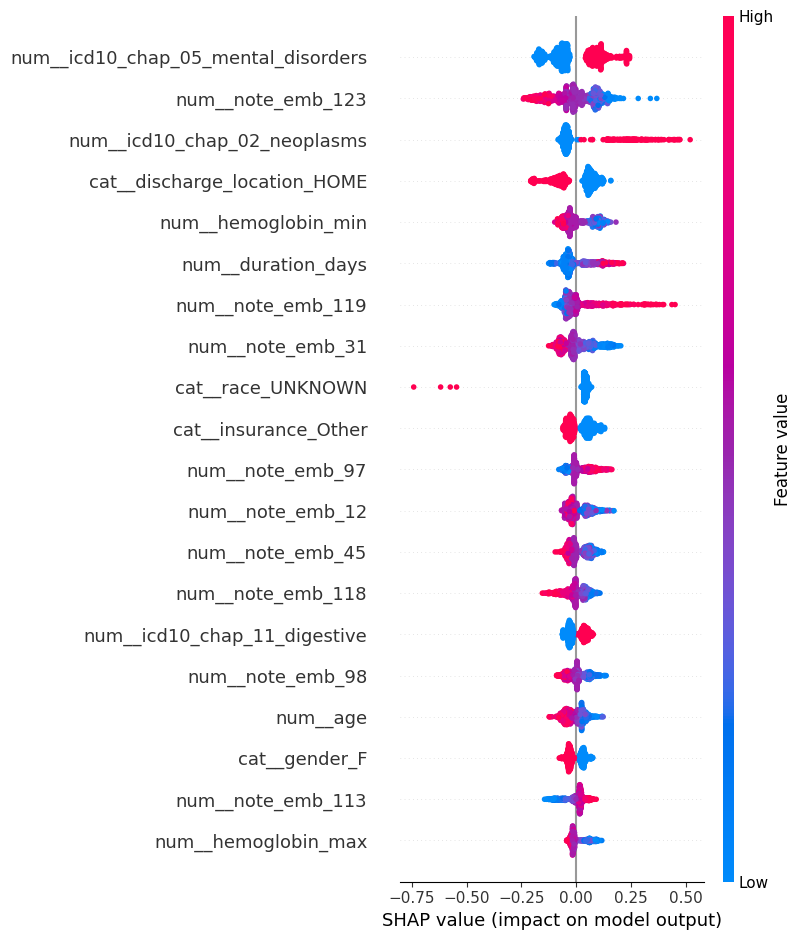

In [8]:
# =========================
# GLOBAL SHAP IMPORTANCE
# =========================

GLOBAL_SAMPLE_SIZE = min(1000, len(X_test))
X_global = X_test.sample(n=GLOBAL_SAMPLE_SIZE, random_state=42)

shap_values_global = explainer.shap_values(X_global)
if isinstance(shap_values_global, list):
    shap_values_global = shap_values_global[1]
if hasattr(shap_values_global, "values"):
    shap_values_global = shap_values_global.values

mean_abs_shap = np.abs(shap_values_global).mean(axis=0)

global_importance = pd.DataFrame({
    "feature": feature_names_processed,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False)

print("Top 20 global SHAP features:")
display(global_importance.head(20))

# Optional plot in notebook
shap.summary_plot(shap_values_global, X_global, max_display=20, show=True)

## 8. Post-process SHAP thành explanation dễ hiểu

Raw SHAP chỉ có `feature`, `value`, `shap_value`. Phần dưới chuyển nó thành explanation card để dùng trong báo cáo/demo model.

In [9]:
# =========================
# SHAP POST-PROCESSING
# =========================

HIDE_NOTE_EMBEDDINGS_IN_EXPLANATION = True

FEATURE_DISPLAY_NAMES = {
    "age": "Tuổi",
    "gender": "Giới tính",
    "duration_days": "Thời gian nằm viện",
    "spo2_mean": "Độ bão hòa oxy trung bình",
    "spo2_min": "Độ bão hòa oxy thấp nhất",
    "sbp_mean": "Huyết áp tâm thu trung bình",
    "sbp_min": "Huyết áp tâm thu thấp nhất",
    "hr_mean": "Nhịp tim trung bình",
    "hr_max": "Nhịp tim cao nhất",
    "temperature_mean": "Nhiệt độ trung bình",
    "creatinine_mean": "Creatinine trung bình",
    "bun_mean": "BUN trung bình",
    "wbc_mean": "Bạch cầu trung bình",
    "lactate_mean": "Lactate trung bình",
    "albumin_mean": "Albumin trung bình",
    "discharge_location": "Phương án xuất viện",
}

def strip_prefix(feature: str) -> str:
    return feature.split("__", 1)[1] if "__" in feature else feature

def parse_feature(feature: str):
    f = strip_prefix(feature)
    if f.startswith("discharge_location_"):
        return "discharge_location", f.replace("discharge_location_", "")
    if f.startswith("gender_"):
        return "gender", f.replace("gender_", "")
    return f, None

def is_note_embedding(feature: str) -> bool:
    f = strip_prefix(feature)
    return f.startswith("note_emb_") or "note_emb_" in f

def is_displayable_feature(feature: str) -> bool:
    if HIDE_NOTE_EMBEDDINGS_IN_EXPLANATION and is_note_embedding(feature):
        return False
    return True

def display_name(feature: str) -> str:
    base, category = parse_feature(feature)
    if base == "discharge_location":
        return f"Phương án xuất viện: {category}" if category else "Phương án xuất viện"
    if base == "gender":
        return f"Giới tính: {category}" if category else "Giới tính"
    if base.startswith("icd10_chap_") or base.startswith("icd_chap_"):
        cleaned = base.replace("icd10_chap_", "").replace("icd_chap_", "").replace("_", " ")
        return f"Nhóm chẩn đoán ICD: {cleaned}"
    if is_note_embedding(feature):
        return "Biểu diễn văn bản lâm sàng"
    return FEATURE_DISPLAY_NAMES.get(base, base.replace("_", " "))

def format_value(feature: str, value):
    base, category = parse_feature(feature)
    if category is not None:
        return "Có" if float(value) >= 0.5 else "Không"
    try:
        v = float(value)
    except Exception:
        return str(value)
    if base == "age":
        return f"{v:.0f} tuổi"
    if "spo2" in base:
        return f"{v:.0f}%"
    if "sbp" in base:
        return f"{v:.0f} mmHg"
    if "hr" in base:
        return f"{v:.0f} bpm"
    if base == "duration_days":
        return f"{v:.1f} ngày"
    if "creatinine" in base:
        return f"{v:.2f} mg/dL"
    if "lactate" in base:
        return f"{v:.2f} mmol/L"
    return f"{v:.2f}"

def impact_level(abs_shap: float, all_abs_values) -> str:
    if len(all_abs_values) == 0:
        return "low"
    p75 = np.percentile(all_abs_values, 75)
    p50 = np.percentile(all_abs_values, 50)
    if abs_shap >= p75:
        return "high"
    if abs_shap >= p50:
        return "medium"
    return "low"

def clinical_sentence(feature: str, value, direction: str) -> str:
    base, category = parse_feature(feature)
    inc = direction == "increase_risk"

    if base == "age":
        return "Tuổi cao là yếu tố làm tăng nguy cơ tái nhập viện sau xuất viện." if inc else "Tuổi của bệnh nhân làm giảm một phần nguy cơ tái nhập viện."
    if "spo2" in base:
        return "Độ bão hòa oxy thấp phản ánh tình trạng hô hấp chưa ổn định, tăng nguy cơ tái nhập viện." if inc else "Độ bão hòa oxy ổn định làm giảm một phần nguy cơ tái nhập viện."
    if "sbp" in base:
        return "Huyết áp bất thường làm tăng nguy cơ tái nhập viện sau xuất viện." if inc else "Huyết áp tương đối ổn định làm giảm một phần nguy cơ tái nhập viện."
    if "hr" in base:
        return "Nhịp tim bất thường làm tăng nguy cơ tái nhập viện." if inc else "Nhịp tim ổn định làm giảm một phần nguy cơ tái nhập viện."
    if "creatinine" in base or "bun" in base:
        return "Dấu hiệu chức năng thận bất thường làm tăng nguy cơ tái nhập viện." if inc else "Chức năng thận ít bất thường hơn làm giảm một phần nguy cơ tái nhập viện."
    if "wbc" in base or "lactate" in base:
        return "Dấu hiệu nhiễm trùng hoặc stress sinh lý làm tăng nguy cơ tái nhập viện." if inc else "Các chỉ dấu viêm/stress thấp hơn làm giảm một phần nguy cơ tái nhập viện."
    if base.startswith("icd"):
        return "Nhóm chẩn đoán này làm tăng nguy cơ tái nhập viện." if inc else "Việc không có/ít liên quan tới nhóm chẩn đoán này làm giảm nguy cơ tái nhập viện."
    if base == "discharge_location":
        return "Trong dữ liệu lịch sử, phương án xuất viện này liên quan tới nguy cơ tái nhập viện cao hơn." if inc else "Trong dữ liệu lịch sử, phương án xuất viện này liên quan tới nguy cơ tái nhập viện thấp hơn."

    return f"{display_name(feature)} làm {'tăng' if inc else 'giảm'} nguy cơ tái nhập viện."

def make_card(feature: str, value, shap_val: float, all_abs_values):
    direction = "increase_risk" if shap_val > 0 else "decrease_risk"
    return {
        "feature": strip_prefix(feature),
        "display_name": display_name(feature),
        "display_value": format_value(feature, value),
        "direction": direction,
        "impact": "Tăng nguy cơ" if direction == "increase_risk" else "Giảm nguy cơ",
        "importance": impact_level(abs(float(shap_val)), all_abs_values),
        "shap_value": round(float(shap_val), 6),
        "explanation": clinical_sentence(feature, value, direction),
    }

## 9. Local explanation cho một bệnh nhân

Hàm này chỉ chạy trong notebook/modeling. Không có API hay deploy ở đây.

In [10]:
# =========================
# LOCAL EXPLANATION
# =========================

def transform_raw_patient(patient_raw: pd.DataFrame) -> pd.DataFrame:
    X_raw = patient_raw[feature_cols].copy()
    X_processed = preprocessor.transform(X_raw)
    return pd.DataFrame(X_processed, columns=feature_names_processed)

def get_shap_array(X_processed: pd.DataFrame):
    vals = explainer.shap_values(X_processed)
    if isinstance(vals, list):
        vals = vals[1]
    if hasattr(vals, "values"):
        vals = vals.values
    return np.asarray(vals)

def explain_patient_for_modeling(patient_raw: pd.DataFrame, top_k: int = 5, include_raw: bool = False):
    Xp = transform_raw_patient(patient_raw)
    risk = float(xai_model.predict_proba(Xp)[0, 1])
    shap_row = get_shap_array(Xp)[0]

    all_abs_displayable = [
        abs(v) for f, v in zip(feature_names_processed, shap_row)
        if is_displayable_feature(f)
    ]

    raw_rows = []
    cards = []
    for feature, value, sv in zip(feature_names_processed, Xp.iloc[0], shap_row):
        raw_rows.append({
            "feature": strip_prefix(feature),
            "value": float(value),
            "shap_value": float(sv),
            "direction": "increase_risk" if sv > 0 else "decrease_risk",
        })
        if is_displayable_feature(feature):
            cards.append(make_card(feature, value, sv, all_abs_displayable))

    cards = sorted(cards, key=lambda x: abs(x["shap_value"]), reverse=True)
    top_risk = [c for c in cards if c["direction"] == "increase_risk"][:top_k]
    top_protective = [c for c in cards if c["direction"] == "decrease_risk"][:top_k]

    result = {
        "task": TASK,
        "target": cfg["target_name"],
        cfg["risk_key"]: round(risk, 4),
        "risk_percent": round(risk * 100, 1),
        "top_risk_factors": top_risk,
        "top_protective_factors": top_protective,
        "note": "SHAP giải thích hành vi của auxiliary XGBoost model, không phải bằng chứng nhân quả.",
    }

    if include_raw:
        result["raw_shap"] = sorted(raw_rows, key=lambda x: abs(x["shap_value"]), reverse=True)

    return result

## 10. Demo local explanation trong notebook

Đây là output để nhóm xem và chụp màn hình/đưa vào báo cáo model, không phải response deploy.

In [11]:
# =========================
# DEMO LOCAL EXPLANATION
# =========================

sample_idx = 0
sample_patient = df_test_clean.iloc[[sample_idx]].copy()

print("Sample index:", sample_idx)
if "hadm_id" in sample_patient.columns:
    print("hadm_id:", sample_patient["hadm_id"].iloc[0])
if "subject_id" in sample_patient.columns:
    print("subject_id:", sample_patient["subject_id"].iloc[0])

local_explanation = explain_patient_for_modeling(sample_patient, top_k=5, include_raw=False)
print(json.dumps(local_explanation, indent=2, ensure_ascii=False))

Sample index: 0
hadm_id: 20000057
subject_id: 11146739
{
  "task": "readmission",
  "target": "30-day readmission risk",
  "risk_30d": 0.233,
  "risk_percent": 23.3,
  "top_risk_factors": [
    {
      "feature": "discharge_location_HOME",
      "display_name": "Phương án xuất viện: HOME",
      "display_value": "Không",
      "direction": "increase_risk",
      "impact": "Tăng nguy cơ",
      "importance": "high",
      "shap_value": 0.051507,
      "explanation": "Trong dữ liệu lịch sử, phương án xuất viện này liên quan tới nguy cơ tái nhập viện cao hơn."
    },
    {
      "feature": "insurance_Other",
      "display_name": "insurance Other",
      "display_value": "0.00",
      "direction": "increase_risk",
      "impact": "Tăng nguy cơ",
      "importance": "high",
      "shap_value": 0.042763,
      "explanation": "insurance Other làm tăng nguy cơ tái nhập viện."
    },
    {
      "feature": "race_UNKNOWN",
      "display_name": "race UNKNOWN",
      "display_value": "0.00",
   

## 11. Model-level What-If experiment: HOME → SNF

Đây chỉ là thí nghiệm trong notebook để xem model đổi prediction thế nào khi đổi `discharge_location`. Không phải triển khai hệ thống.

Lưu ý: kết quả này là model-based counterfactual, không chứng minh SNF gây tăng/giảm nguy cơ tái nhập viện.

In [12]:
# =========================
# MODEL-LEVEL WHAT-IF EXPERIMENT
# =========================

def apply_discharge_option_for_experiment(patient_raw: pd.DataFrame, option: str) -> pd.DataFrame:
    x = patient_raw.copy()
    if "discharge_location" not in x.columns:
        raise KeyError(
            "Không tìm thấy cột discharge_location trong Gold. "
            "Nếu chỉ có discharge_location_enc thì nên giữ lại cột category để xAI dễ giải thích."
        )
    x["discharge_location"] = option
    return x

def compare_discharge_options_for_modeling(
    patient_raw: pd.DataFrame,
    baseline_option: str = "HOME",
    scenario_option: str = "SNF",
    top_k: int = 5,
):
    base_patient = apply_discharge_option_for_experiment(patient_raw, baseline_option)
    scenario_patient = apply_discharge_option_for_experiment(patient_raw, scenario_option)

    base_exp = explain_patient_for_modeling(base_patient, top_k=top_k)
    scenario_exp = explain_patient_for_modeling(scenario_patient, top_k=top_k)

    base_risk = base_exp[cfg["risk_key"]]
    scenario_risk = scenario_exp[cfg["risk_key"]]
    delta = scenario_risk - base_risk

    if delta > 0:
        text = f"{scenario_option} làm predicted risk tái nhập viện tăng {abs(delta)*100:.1f}% so với {baseline_option}."
    elif delta < 0:
        text = f"{scenario_option} làm predicted risk tái nhập viện giảm {abs(delta)*100:.1f}% so với {baseline_option}."
    else:
        text = f"{scenario_option} không làm thay đổi predicted risk tái nhập viện so với {baseline_option}."

    return {
        "task": TASK,
        "target": cfg["target_name"],
        "baseline_option": baseline_option,
        "scenario_option": scenario_option,
        "baseline_risk": base_risk,
        "scenario_risk": scenario_risk,
        "delta_risk": round(delta, 4),
        "summary": text,
        "scenario_top_risk_factors": scenario_exp["top_risk_factors"],
        "scenario_top_protective_factors": scenario_exp["top_protective_factors"],
        "disclaimer": "Đây là thí nghiệm counterfactual dựa trên model, không phải causal inference.",
    }

baseline_option = cfg["baseline_option"]
scenario_option = cfg["scenario_option"]

try:
    whatif_experiment = compare_discharge_options_for_modeling(
        sample_patient,
        baseline_option=baseline_option,
        scenario_option=scenario_option,
        top_k=5,
    )
    print(json.dumps(whatif_experiment, indent=2, ensure_ascii=False))
except Exception as e:
    print("Không chạy được What-If experiment:", repr(e))
    print("Gợi ý: kiểm tra cột discharge_location và giá trị HOME/SNF trong Gold.")

{
  "task": "readmission",
  "target": "30-day readmission risk",
  "baseline_option": "HOME",
  "scenario_option": "SNF",
  "baseline_risk": 0.2263,
  "scenario_risk": 0.233,
  "delta_risk": 0.0067,
  "summary": "SNF làm predicted risk tái nhập viện tăng 0.7% so với HOME.",
  "scenario_top_risk_factors": [
    {
      "feature": "discharge_location_HOME",
      "display_name": "Phương án xuất viện: HOME",
      "display_value": "Không",
      "direction": "increase_risk",
      "impact": "Tăng nguy cơ",
      "importance": "high",
      "shap_value": 0.051507,
      "explanation": "Trong dữ liệu lịch sử, phương án xuất viện này liên quan tới nguy cơ tái nhập viện cao hơn."
    },
    {
      "feature": "insurance_Other",
      "display_name": "insurance Other",
      "display_value": "0.00",
      "direction": "increase_risk",
      "impact": "Tăng nguy cơ",
      "importance": "high",
      "shap_value": 0.042763,
      "explanation": "insurance Other làm tăng nguy cơ tái nhập viện."

## 12. Lưu kết quả model/xAI artifacts

Phần này chỉ lưu file model để reproducibility hoặc nộp kèm kết quả. Không phải deploy.

In [13]:
# =========================
# SAVE MODEL-ONLY ARTIFACTS
# =========================

joblib.dump(xai_model, os.path.join(OUTPUT_DIR, "xai_auxiliary_model.joblib"))
joblib.dump(preprocessor, os.path.join(OUTPUT_DIR, "xai_preprocessor.joblib"))
joblib.dump(explainer, os.path.join(OUTPUT_DIR, "xai_shap_explainer.joblib"))

with open(os.path.join(OUTPUT_DIR, "feature_cols_raw.json"), "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

with open(os.path.join(OUTPUT_DIR, "feature_names_processed.json"), "w", encoding="utf-8") as f:
    json.dump(feature_names_processed, f, ensure_ascii=False, indent=2)

metrics = {
    "task": TASK,
    "label_col": LABEL_COL,
    "target_name": cfg["target_name"],
    "auc": float(auc),
    "average_precision": float(ap),
    "positive_rate_train": float(y_train.mean()),
    "positive_rate_test": float(y_test.mean()),
    "note": "Model-only xAI artifacts. No deployment code included."
}

with open(os.path.join(OUTPUT_DIR, "xai_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("Saved model-only artifacts to:", OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))

Saved model-only artifacts to: xai_model_only_readmission
['xai_metrics.json', 'xai_preprocessor.joblib', 'xai_auxiliary_model.joblib', 'feature_names_processed.json', 'xai_shap_explainer.joblib', 'feature_cols_raw.json']


## 13. Kết luận

Notebook này dừng ở phạm vi model:
- Train auxiliary XGBoost model cho xAI readmission.
- Tính global/local SHAP.
- Post-process SHAP thành explanation dễ hiểu.
- Chạy thử What-If HOME → SNF trong notebook.
- Lưu artifacts để tái lập kết quả.

Không có FastAPI, không có frontend, không có deploy.